In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [28]:
df= pd.read_csv('solar_leads_merged')

In [29]:
model_data = df[
    [
        "distance_from_darab_km",
        "property_type",
        "usage_purpose",
        "electricity_access",
        "lead_source",
        "required_appliances",
        "estimated_daily_energy_need_kwh",
        "quoted_price_m_toman",
        "purchased"
    ]
].copy()

In [30]:
model_data.isna().sum()

distance_from_darab_km              0
property_type                       0
usage_purpose                      12
electricity_access                  0
lead_source                        12
required_appliances                 0
estimated_daily_energy_need_kwh     0
quoted_price_m_toman                0
purchased                           0
dtype: int64

In [31]:
model_data["usage_purpose"] = model_data["usage_purpose"].fillna(
    model_data["usage_purpose"].mode()[0]
)

model_data["lead_source"] = model_data["lead_source"].fillna(
    model_data["lead_source"].mode()[0]
)

In [32]:
x = model_data.drop("purchased", axis=1)
y = model_data["purchased"]

In [33]:
x_encoded = pd.get_dummies(x,columns=["property_type",
    "usage_purpose",
    "electricity_access",
    "lead_source",
    "required_appliances"],dtype=int)

In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    x_encoded,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# split
x_train, x_test, y_train, y_test = train_test_split(
    x_encoded,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# numerical columns
num_cols = [
    "distance_from_darab_km",
    "estimated_daily_energy_need_kwh",
    "quoted_price_m_toman"
]

# scaler
scaler = StandardScaler()

# copy data
x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

# scale only numerical columns
x_train_scaled[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test_scaled[num_cols] = scaler.transform(x_test[num_cols])

In [12]:
log_pred = log_model.predict(x_test)

In [13]:
accuracy_score(y_test, log_pred)

0.4

In [25]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.68      0.53      0.59        36
           1       0.73      0.83      0.78        54

    accuracy                           0.71        90
   macro avg       0.70      0.68      0.68        90
weighted avg       0.71      0.71      0.70        90



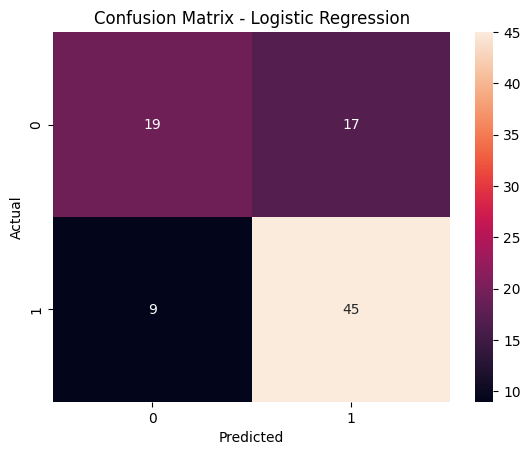

In [29]:
cm = confusion_matrix(y_test, log_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# split
x_train, x_test, y_train, y_test = train_test_split(
    x_encoded,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


log_model = LogisticRegression(max_iter=5000,  solver="liblinear",random_state=42)

log_model.fit(x_train, y_train)

log_pred = log_model.predict(x_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))


Logistic Regression Accuracy: 0.7222222222222222
              precision    recall  f1-score   support

           0       0.70      0.53      0.60        36
           1       0.73      0.85      0.79        54

    accuracy                           0.72        90
   macro avg       0.72      0.69      0.69        90
weighted avg       0.72      0.72      0.71        90



In [36]:
cm = confusion_matrix(y_test, log_pred)
cm

array([[19, 17],
       [ 8, 46]])

In [10]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [11]:
tree_pred = tree_model.predict(x_test)

In [12]:
accuracy_score(y_test, tree_pred)

0.5555555555555556

In [13]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.46      0.61      0.52        36
           1       0.67      0.52      0.58        54

    accuracy                           0.56        90
   macro avg       0.56      0.56      0.55        90
weighted avg       0.58      0.56      0.56        90



In [14]:
rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [16]:
rf_pred = rf_model.predict (x_test)

In [17]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.55      0.50      0.52        36
           1       0.68      0.72      0.70        54

    accuracy                           0.63        90
   macro avg       0.61      0.61      0.61        90
weighted avg       0.63      0.63      0.63        90



In [18]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.7111111111111111
Decision Tree Accuracy: 0.5555555555555556
Random Forest Accuracy: 0.6333333333333333


All categorical variables were converted into numerical format using one-hot encoding, because scikit-learn models cannot directly work with text values. This encoding step was applied to all classification models, including Logistic Regression, Decision Tree, and Random Forest.

Feature scaling was tested for Logistic Regression because this model can be sensitive to the scale of numerical features. To avoid data leakage, the scaler was fitted only on the training data and then used to transform the test data.

However, Logistic Regression was tested with and without feature scaling. In this dataset, the unscaled version performed better. This may be because quoted price and estimated energy need are strong business signals, and scaling reduced their relative influence compared with one-hot encoded categorical variables. Therefore, the unscaled Logistic Regression model was kept as the baseline model.

In contrast, Decision Tree and Random Forest models were trained without scaling, because tree-based models are not sensitive to feature scale. Therefore, the encoded but unscaled data was used for these models.

Logistic Regression was selected as the final model because it achieved the highest accuracy among the tested models. The model was trained on one-hot encoded data without scaling, since the unscaled version performed better in this dataset. The solver was changed to liblinear to improve convergence for this small binary classification problem.

In [37]:
final_model = LogisticRegression(
    max_iter=5000,
    solver="liblinear",
    random_state=42
)

final_model.fit(x_encoded, y)

LogisticRegression(max_iter=5000, random_state=42, solver='liblinear')

In [38]:
purchase_probabilities = final_model.predict_proba(x_encoded)[:, 1]

In [39]:
df_scored = df.copy()

df_scored["purchase_probability"] = purchase_probabilities

In [40]:
df_scored["lead_score"] = df_scored["purchase_probability"] * 100
df_scored["lead_score"] = df_scored["lead_score"].round(1)

In [42]:
df_scored["priority_level"] = pd.cut(
    df_scored["lead_score"],
    bins=[0, 40, 70, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [43]:
df_scored[
    [
        "lead_id",
        "property_type",
        "usage_purpose",
        "electricity_access",
        "required_appliances",
        "estimated_daily_energy_need_kwh",
        "quoted_price_m_toman",
        "purchase_probability",
        "lead_score",
        "priority_level"
    ]
].head(10)

,lead_id,property_type,usage_purpose,electricity_access,required_appliances,estimated_daily_energy_need_kwh,quoted_price_m_toman,purchase_probability,lead_score,priority_level
0,L0001,garden_house,mixed_use,none,"pump,lights",10.0,628.7,0.562716,56.3,Medium
1,L0002,rural_house,seasonal_garden,none,"lights,TV",2.5,151.0,0.492726,49.3,Medium
2,L0003,garden_house,mixed_use,none,"lights,fridge,TV",4.5,284.1,0.536800,53.7,Medium
3,L0004,garden_house,seasonal_garden,unstable,"lights,fridge",4.7,286.8,0.237420,23.7,Low
4,L0005,garden_house,mixed_use,unstable,"lights,fridge",5.1,282.2,0.488387,48.8,Medium
5,L0006,garden_house,seasonal_garden,unstable,"AC,fridge,lights",10.9,586.2,0.228697,22.9,Low
6,L0007,garden_house,mixed_use,unstable,"AC,fridge",9.1,378.0,0.294567,29.5,Low
7,L0008,farm,agriculture,unstable,"pump,fridge",11.1,761.7,0.809788,81.0,High
8,L0009,rural_house,seasonal_garden,none,"lights,TV",2.3,138.7,0.529022,52.9,Medium
9,L0010,garden_house,seasonal_garden,none,lights,1.3,96.5,0.193234,19.3,Low


In [44]:
top_leads = df_scored.sort_values("lead_score", ascending=False)

top_leads[
    [
        "lead_id",
        "village",
        "property_type",
        "usage_purpose",
        "electricity_access",
        "required_appliances",
        "quoted_price_m_toman",
        "lead_score",
        "priority_level"
    ]
].head(20)

,lead_id,village,property_type,usage_purpose,electricity_access,required_appliances,quoted_price_m_toman,lead_score,priority_level
52,L0053,Banouj,farm,agriculture,none,"pump,AC",795.0,93.9,High
41,L0042,Pasakhan,farm,agriculture,none,"pump,AC",749.3,93.4,High
136,L0137,Shahanan,farm,agriculture,none,"pump,AC",761.5,92.6,High
91,L0092,Khosouyeh,farm,agriculture,none,"pump,AC",817.2,91.2,High
15,L0016,Rostaq,farm,agriculture,none,"pump,AC",723.2,90.5,High
54,L0055,Jamsi,farm,mixed_use,unstable,"pump,AC",669.0,90.2,High
130,L0131,Banouj,farm,agriculture,none,"pump,AC",718.7,89.4,High
68,L0069,Banouj,farm,agriculture,none,"pump,AC",741.9,88.8,High
287,L0288,Nidshahr,farm,agriculture,none,pump,591.5,88.1,High
17,L0018,Jamsi,farm,agriculture,none,pump,621.0,87.8,High


In [45]:
df_scored["priority_level"].value_counts()

priority_level
High      119
Medium    118
Low        63
Name: count, dtype: int64

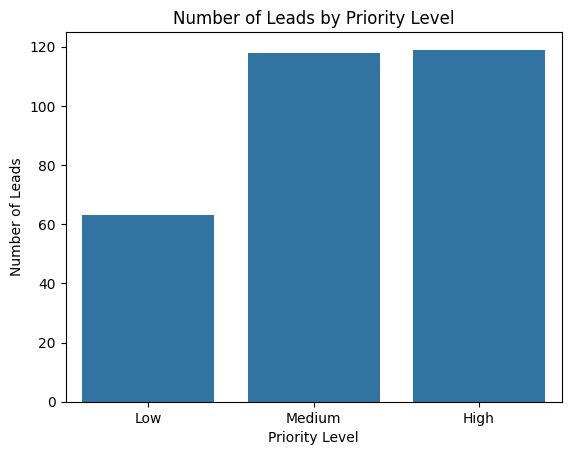

In [46]:
sns.countplot(data=df_scored, x="priority_level")

plt.title("Number of Leads by Priority Level")
plt.xlabel("Priority Level")
plt.ylabel("Number of Leads")
plt.show()

In [47]:
df_scored.groupby("priority_level")["purchased"].mean() * 100

C:\Users\azarakhsh\AppData\Local\Temp\ipykernel_9852\1191550598.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_scored.groupby("priority_level")["purchased"].mean() * 100


priority_level
Low       26.984127
Medium    55.084746
High      82.352941
Name: purchased, dtype: float64

## Lead Scoring Summary

After selecting Logistic Regression as the final classification model, purchase probabilities were generated for each lead. These probabilities were converted into lead scores from 0 to 100. Leads were then grouped into Low, Medium, and High priority levels. This scoring system helps the sales team prioritize leads based on their estimated likelihood of purchasing a solar system.

In [48]:
df_scored.to_csv('solar_leads_scored.csv')

In [49]:
df_scored.head(5)

,lead_id,village,distance_from_darab_km,property_type,usage_purpose,electricity_access,lead_source,required_appliances,estimated_daily_energy_need_kwh,quoted_price_m_toman,purchased,purchase_probability,lead_score,priority_level
0,L0001,Hasan Abad,14.9,garden_house,mixed_use,none,referral,"pump,lights",10.0,628.7,1,0.562716,56.3,Medium
1,L0002,Madavan,32.1,rural_house,seasonal_garden,none,referral,"lights,TV",2.5,151.0,1,0.492726,49.3,Medium
2,L0003,Layzangan,82.1,garden_house,mixed_use,none,referral,"lights,fridge,TV",4.5,284.1,0,0.536800,53.7,Medium
3,L0004,Dabiran,70.6,garden_house,seasonal_garden,unstable,local_ad,"lights,fridge",4.7,286.8,0,0.237420,23.7,Low
4,L0005,Jannat Shahr,24.8,garden_house,mixed_use,unstable,instagram,"lights,fridge",5.1,282.2,1,0.488387,48.8,Medium


## Lead Scoring Summary

After selecting Logistic Regression as the final classification model, purchase probabilities were generated for each lead. These probabilities were converted into lead scores from 0 to 100. Leads were then grouped into Low, Medium, and High priority levels. This scoring system helps the sales team prioritize leads based on their estimated likelihood of purchasing a solar system.

In [50]:
feature_importance = pd.DataFrame({
    "feature": x_encoded.columns,
    "coefficient": final_model.coef_[0]
})

feature_importance = feature_importance.sort_values("coefficient", ascending=False)

feature_importance.head(15)

,feature,coefficient
23,"required_appliances_pump,AC",0.988843
6,usage_purpose_agriculture,0.669573
15,lead_source_returning_customer,0.612718
3,property_type_farm,0.528764
20,"required_appliances_lights,fridge",0.339236
14,lead_source_referral,0.252853
10,electricity_access_none,0.252516
7,usage_purpose_mixed_use,0.244442
22,required_appliances_pump,0.097313
19,"required_appliances_lights,TV",0.081031


In [51]:
feature_importance = feature_importance.sort_values("coefficient", ascending=False)

In [52]:
feature_importance

,feature,coefficient
23,"required_appliances_pump,AC",0.988843
6,usage_purpose_agriculture,0.669573
15,lead_source_returning_customer,0.612718
3,property_type_farm,0.528764
20,"required_appliances_lights,fridge",0.339236
14,lead_source_referral,0.252853
10,electricity_access_none,0.252516
7,usage_purpose_mixed_use,0.244442
22,required_appliances_pump,0.097313
19,"required_appliances_lights,TV",0.081031


In [53]:
feature_importance.head(15)

,feature,coefficient
23,"required_appliances_pump,AC",0.988843
6,usage_purpose_agriculture,0.669573
15,lead_source_returning_customer,0.612718
3,property_type_farm,0.528764
20,"required_appliances_lights,fridge",0.339236
14,lead_source_referral,0.252853
10,electricity_access_none,0.252516
7,usage_purpose_mixed_use,0.244442
22,required_appliances_pump,0.097313
19,"required_appliances_lights,TV",0.081031


In [54]:
feature_importance.tail(15)

,feature,coefficient
5,property_type_rural_house,0.011836
2,quoted_price_m_toman,0.001120
11,electricity_access_unstable,-0.006057
17,"required_appliances_AC,fridge,lights",-0.006697
0,distance_from_darab_km,-0.007012
8,usage_purpose_primary_residence,-0.041572
1,estimated_daily_energy_need_kwh,-0.076710
24,"required_appliances_pump,fridge",-0.177614
25,"required_appliances_pump,lights",-0.282209
13,lead_source_local_ad,-0.291896


Model Interpretation

The Logistic Regression coefficients provide useful business insight into which customer characteristics are associated with higher or lower purchase probability.

The strongest positive drivers of purchase are related to practical energy need and stronger customer intent. Leads requiring pump and AC systems, agriculture use cases, farms, customers without electricity access, returning customers, and referral leads are associated with higher purchase likelihood. These patterns match the business context, because these customers usually have a stronger and more urgent need for an off-grid solar system.

The strongest negative drivers are related to weaker or less urgent demand. Seasonal garden use, light-only appliance needs, Instagram leads, garden houses, and local advertisement leads are associated with lower purchase likelihood. These leads may still be valuable, but they may require more follow-up, education, or lower-cost system options.

Numerical coefficients should be interpreted carefully because the final Logistic Regression model was kept without feature scaling. Therefore, coefficients for numerical variables such as quoted price, distance, and energy need are not directly comparable with one-hot encoded categorical coefficients. The interpretation is mainly directional and business-oriented rather than causal.